# DP multi-component workflow (test)

Mirrors `dp_workflow.ipynb` but drives the refactored `src/DP_new.py`.
Key API changes vs. the old two-component `DP`:

- `fit_all` returns **`(dp_parent, dp_components, model_cube)`** instead of L/R arrays.
- `dp_parent`: one scalar row per galaxy (Z, mass, chosen `N_COMP`, BIC/chi2 per N, total flux per line).
- `dp_components`: **tidy/long** table, one row per (target, component, line).
- `bpt_classification` / `estimate_SFR` / `select_dp_sample` consume `dp_components`.
- `plot_fit` overlays every component for a target.

In [ ]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp_0712.fits',
    'dps' : './catalogs/test_dps_multicomp_0712.fits',
}

## Build the sample: keep sources with >=1 significant emission line (>5 S/N)

In [4]:
FIT = FitSpectrum()
DP  = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 30.67 seconds.
Total number of spectra: 99812


In [5]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('After significant-emission filter:', len(ALL_SPECTRA.targetID))

After significant-emission filter: 57271


In [6]:
# --- TEST MODE: thin the sample so a full 1..4-component fit runs quickly ---
# Comment this out for a production run.
# ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(10)
print('After shrinking:', len(ALL_SPECTRA.targetID))

After shrinking: 57271


In [7]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380056197,177.003822,-1.903397,0.224113,GALAXY,10.250155,-0.348563,False,False,False,True,False,False
1,39627739380056420,177.013472,-1.972766,0.102005,GALAXY,9.722920,-0.349153,False,False,False,True,False,False
2,39627739380056564,177.019312,-1.965308,0.323187,GALAXY,10.452706,0.941032,False,False,False,True,True,True
3,39627739380056768,177.028143,-1.960056,0.102814,GALAXY,10.143390,0.193251,True,False,False,True,True,True
4,39627739380056864,177.032977,-1.909970,0.167324,GALAXY,10.575973,-9.632146,False,False,False,True,True,False


## Fit everything
For each target, `fit_dp` fits N = 1..4 velocity components, picks N by minimum BIC,
and emits a scalar parent row + tidy per-(component, line) rows + the best-fit model.

In [8]:
dp_parent, dp_components, model_cube = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print('parent    :', dp_parent.shape)
print('components:', dp_components.shape)
print('model cube:', model_cube.shape)
print('N_COMP distribution:')
print(dp_parent['N_COMP'].value_counts().sort_index())

100%|██████████| 57271/57271 [1:16:54<00:00, 12.41it/s]


parent    : (57271, 26)
components: (752190, 14)
model cube: (57271, 7781)
N_COMP distribution:
N_COMP
1    41204
2    14322
3     1609
4      136
Name: count, dtype: int64


In [9]:
dp_parent[dp_parent['N_COMP']==1].head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,1,1,807.014282,746.630554,...,2.234996,2.974765,2.358496,0.383114,1.160451,1.938171,5.943389,14.052762,1.258454,2.053484
1,39627739380056420,177.013474,-1.972766,0.102005,9.722919,-0.349153,1,1,749.587891,690.067444,...,2.793715,3.718417,3.139801,0.486163,1.472587,1.361834,4.176056,15.036660,4.805563,0.152118
2,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,1,1,945.812256,884.752136,...,6.948431,9.248316,5.847884,3.138156,9.505466,4.574345,14.027199,34.161686,6.503983,4.075818
3,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,1,1,778.641907,719.194214,...,9.519390,12.670244,11.370088,3.000140,9.087415,6.037732,18.514666,59.799660,13.045617,10.133431
4,39627739380056864,177.032974,-1.909970,0.167324,10.575974,-9.632146,1,1,842.335876,782.310425,...,4.496521,5.984840,6.231286,1.670814,5.060892,7.304663,22.399700,31.581421,8.945649,7.590318


## Persist to FITS and round-trip

In [10]:
DP.get_catalog(dp_parent, dp_components, model_cube, fname=filenames['all'])


In [11]:

dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (57271, 26) (752190, 14) (57271, 7781)


## Per-component science: BPT and SFR
Both now return one result **per component** instead of a fixed L/R pair.

In [12]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:491: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,0,1,uncertain,upper_limit
1,39627739380056420,0,1,uncertain,upper_limit
2,39627739380056564,0,4,lower_limit,measured
3,39627739380056768,0,1,measured,measured
4,39627739380056864,0,4,uncertain,measured
5,39627739380057310,0,1,measured,upper_limit
6,39627739380057506,0,4,uncertain,measured
7,39627739380057763,0,1,uncertain,measured
8,39627739380057763,1,4,upper_limit,measured
9,39627739380058028,0,1,upper_limit,measured


In [13]:
per_comp_sfr, dp_parent = DP.estimate_SFR(dp_components, dp_parent)
print('total SFR written to parent as LOGSFR_FIT')
per_comp_sfr.head()

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:229: RuntimeWarning: divide by zero encountered in log10
  ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / flux_ratio)
/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:235: RuntimeWarning: overflow encountered in scalar power
  flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17


total SFR written to parent as LOGSFR_FIT


/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:515: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(comp_sfr)


,TARGETID,COMP_IDX,SFR,LOGSFR
0,39627739380056197,0,0.737450,-0.132268
1,39627739380056420,0,0.099626,-1.001626
2,39627739380056564,0,5.910387,0.771616
3,39627739380056768,0,0.515609,-0.287679
4,39627739380056864,0,0.751431,-0.124111


## Select the multi-component (DP+) sample
A galaxy qualifies when its best model has >1 component AND >=2 components are
significantly detected (`SIG`) in the same line.

In [14]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
# dp_sample.sort_values('N_COMP_FIT', ascending=True).head(50)
dp_sample[dp_sample['N_COMP_FIT'] == 4].head(50)

DP+ candidates: 16067 / 57271


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT,LOGSFR_FIT
81,39627739405223617,178.571960,-1.932314,0.305112,10.510936,1.428659,4,4,2235.995117,2174.996338,...,103.936104,100.574982,45.449917,137.667664,45.318317,138.968323,413.442749,72.765602,56.237213,1.401726
117,39627739417808986,179.424606,-1.983819,0.224270,9.888641,1.483569,4,4,1475.027588,1414.687866,...,55.118103,60.930054,28.811197,87.269028,41.540260,127.382935,265.006470,42.188854,18.946934,1.326367
763,39627739677856750,194.987213,-1.948047,0.263218,11.140140,1.411261,4,4,1532.908936,1472.180664,...,29.069334,27.350346,46.683720,141.404846,45.673504,140.057495,123.537750,22.993626,27.291573,1.152439
1354,39627739900152195,208.097778,-1.946778,0.166847,10.860261,-0.254328,4,4,2451.696045,2391.762207,...,294.264099,123.115601,196.901947,596.415405,100.447205,308.020691,525.630005,167.121780,153.237411,0.862574
1471,39627739946287571,210.767715,-1.894657,0.174390,10.527916,1.772754,4,4,2160.485840,2100.380859,...,63.806549,82.645302,33.668770,101.982605,82.047325,251.597580,415.686005,82.945480,60.894360,1.291187
2889,39627745600209940,187.806992,-1.764181,0.283906,10.982166,-8.216452,4,4,1670.350342,1609.475342,...,65.165390,58.026867,45.436573,137.627258,49.817200,152.764114,487.953796,73.650551,66.639496,2.254364
3138,39627745646350987,190.744324,-1.791006,0.111824,9.617455,1.265703,4,4,3905.034424,3845.489990,...,81.561638,76.916580,210.923645,638.887085,48.094933,147.482788,305.221436,54.031349,64.603760,1.374086
3672,39627745742816962,196.329086,-1.840101,0.387289,11.010113,1.139597,4,4,2056.207031,1994.622803,...,14.724125,21.231676,16.049856,48.614971,20.098055,61.630554,89.626495,18.455963,11.124640,1.657897
4110,39627745818317047,200.956894,-1.759034,0.223888,10.505062,-5.230967,4,4,1070.584961,1010.157471,...,56.271973,28.437445,46.538540,140.965103,21.620075,66.297821,87.373100,42.521915,32.063908,-0.017574
4119,39627745822507268,201.010971,-1.868562,0.080284,10.729084,1.450208,4,4,3853.636719,3794.311768,...,27.130123,56.571053,5.183182,15.699844,87.293327,267.684418,467.022003,72.700264,52.058243,1.453534


In [84]:
dp_components[(dp_components['N_COMP']==2)
              & (dp_components['SIGMA']>60)
              & (dp_components['LINE']=='Halpha')
              & (dp_components['SIG']==True)
              & (dp_components['BPT']==16) 
              & (dp_components['OIII_HB_BOUND'] == 'measured')
              & (dp_components['NII_HA_BOUND'] == 'measured')
              & (np.abs(dp_components['DV'])<80)
              ].sort_values('SIGMA', ascending=True).head(50)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
312877,39627775820173645,2,1,Halpha,6564.631836,79.866219,62.299408,28.628258,97.920616,4.761962,34.360249,True,8.549468,False,16,measured,measured
430657,39627788017209863,2,0,Halpha,6564.631836,2.041530,62.329445,11.408719,39.031273,2.971144,13.951493,True,8.392924,False,16,measured,measured
438487,39627788130453117,2,1,Halpha,6564.631836,61.828556,62.757763,24.742245,85.246338,2.697829,30.643167,True,8.345711,False,16,measured,measured
657317,39627812423860350,2,1,Halpha,6564.631836,0.508895,63.480644,51.936607,180.965271,4.252168,46.519791,True,11.670212,False,16,measured,measured
572477,39627805897526727,2,1,Halpha,6564.631836,1.314805,63.855137,22.773178,79.818031,4.054389,36.173512,True,6.619597,False,16,measured,measured
60257,39627745898008834,2,1,Halpha,6564.631836,0.160503,64.131836,19.634680,69.115799,1.940058,21.952930,True,9.445089,False,16,measured,measured
467967,39627793796957324,2,1,Halpha,6564.631836,0.467273,64.353752,9.937662,35.102531,2.737629,11.327249,True,9.296837,False,16,measured,measured
589237,39627806178542166,2,1,Halpha,6564.631836,4.991303,65.174675,32.001019,114.479973,2.913565,30.037695,True,11.433631,False,16,measured,measured
267097,39627769948148377,2,1,Halpha,6564.631836,2.026065,65.432632,45.902351,164.858688,2.835056,63.945343,True,7.734356,False,16,measured,measured
729307,39627824029500560,2,1,Halpha,6564.631836,0.008335,65.990677,12.400718,44.916824,1.417280,19.005964,True,7.089904,False,16,measured,measured


In [594]:
line = 'Halpha'

sub = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'Halpha') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


sub_oiii = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    # & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    # & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


dv_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


dv_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


In [595]:
dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,-259.707825,-19.861252,234.004272,389.022919
39627739417808986,-32.687855,-25.426647,46.873497,61.916325
39627745600209940,-104.932220,-11.085380,97.263062,208.141647
39627745646350987,-147.592712,-126.687866,8.496678,20.428268
39627745818317047,-279.562286,-90.637520,55.222404,106.106567
39627745914786612,-200.000000,-141.292252,8.151497,212.521484
39627751816168436,-139.675522,-19.510895,-5.570243,121.994255
39627751879086086,-67.196190,-12.688194,37.732964,138.211121
39627752202045152,-144.434845,-134.691803,-2.970310,119.305740


In [596]:
len(dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)])

58

In [597]:
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,-259.707825,-19.861252,234.004272,389.022919
39627745600209940,-104.932220,-11.085380,97.263062,208.141647
39627745914786612,-200.000000,-141.292252,8.151497,212.521484
39627746170638653,-167.220001,-68.942047,-68.637344,83.374397
39627751816168436,-139.675522,-19.510895,-5.570243,121.994255
39627752260766820,-61.646755,34.521790,96.852066,354.631073
39627757788857889,-81.558098,-20.108784,3.752838,100.679169
39627758250235053,-600.000000,-152.372299,15.475505,81.038765
39627758296372508,-95.075027,-66.751694,58.104507,100.993523


In [598]:
len(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)])

68

In [599]:
dv_['STD'] = dv_.std(axis=1)
dv_['MAX'] = dv_.max(axis=1)
dv_['MIN'] = dv_.min(axis=1)
dv_['DIFF'] = dv_['MAX'] - dv_['MIN']
dv_['MEAN'] = dv_.mean(axis=1)

dv_['SIG_STD'] = sigma_.std(axis=1)
dv_['SIG_MAX'] = sigma_.max(axis=1)
dv_['SIG_MIN'] = sigma_.min(axis=1)
dv_['SIG_DIFF'] = dv_['SIG_MAX'] - dv_['SIG_MIN']
dv_['SIG_MEAN'] = sigma_.mean(axis=1)

dv_['TARGETID'] = dv_.index
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)].sort_values('SIG_MIN', ascending=True).head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN,SIG_STD,SIG_MAX,SIG_MIN,SIG_DIFF,SIG_MEAN,TARGETID
TARGETID,,,,,,,,,,,,,,,
39627799945806800,-95.517654,-15.300261,46.702248,114.484131,89.463570,114.484131,-95.517654,210.001785,46.100037,65.351189,158.935196,8.619964,150.315231,66.253998,39627799945806800
39627806254044262,-208.541656,-56.545856,99.024818,157.328583,164.546021,164.546021,-208.541656,373.087677,60.612991,60.469112,160.943558,16.580294,144.363266,80.767723,39627806254044262
39627824272773105,-106.683884,-12.073932,25.052696,134.262421,99.615997,134.262421,-106.683884,240.946304,51.087269,40.450550,110.185471,22.177933,88.007538,50.567078,39627824272773105
39627763639911175,-40.962189,-24.467871,109.002907,193.400650,111.837547,193.400650,-40.962189,234.362839,91.951546,98.998657,240.162704,22.715183,217.447525,122.631821,39627763639911175
39627788172395079,-103.171959,-16.536543,6.395783,159.130493,109.173431,159.130493,-103.171959,262.302460,59.156525,38.234089,106.427620,24.055635,82.371986,49.602440,39627788172395079
39627763702829303,-173.905457,-87.287132,110.593071,287.550751,206.631317,287.550751,-173.905457,461.456207,114.835503,28.831465,93.597603,25.049303,68.548302,53.445625,39627763702829303
39627800495263102,-124.365425,-7.557337,87.752205,149.047119,119.288994,149.047119,-124.365425,273.412537,65.282471,129.737396,304.773010,27.283154,277.489868,115.132065,39627800495263102
39627787832658574,-130.933914,-89.711884,128.836807,137.330872,141.577469,141.577469,-130.933914,272.511383,58.781784,77.085640,193.813721,27.324942,166.488785,100.980476,39627787832658574
39627769608408833,-231.194580,-68.064934,0.933914,65.666542,127.624680,127.624680,-231.194580,358.819275,18.776875,173.569427,413.229675,27.465210,385.764465,159.037659,39627769608408833


In [600]:
print(dv_['TARGETID'])

TARGETID
39627739405223617    39627739405223617
39627739417808986    39627739417808986
39627739677856750    39627739677856750
39627739900152195    39627739900152195
39627739946287571    39627739946287571
                           ...        
39627824272773105    39627824272773105
39627824356658981    39627824356658981
39627824386017242    39627824386017242
39627824620898640    39627824620898640
39627824625091499    39627824625091499
Name: TARGETID, Length: 136, dtype: int64


In [611]:
DP.record_ids(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)], fname='4_comp.csv')

In [602]:
sigma_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,92.657356,100.978783,114.698784,31.077894
39627739417808986,27.386272,101.829521,32.924351,NaN
39627739677856750,43.509888,274.190887,98.610298,NaN
39627739900152195,54.785793,210.549225,NaN,78.110962
39627739946287571,NaN,289.222778,85.574738,57.336418
...,...,...,...,...
39627824272773105,22.177933,110.185471,40.466602,29.438303
39627824356658981,375.269196,93.016449,161.197723,74.090813
39627824386017242,373.053345,130.546021,82.404343,123.590096


In [603]:
sigma_['STD'] = sigma_.std(axis=1)
sigma_['MAX'] = sigma_.max(axis=1)
sigma_['MIN'] = sigma_.min(axis=1)
sigma_['DIFF'] = sigma_['MAX'] - sigma_['MIN']
sigma_['MEAN'] = sigma_.mean(axis=1)
sigma_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627739405223617,92.657356,100.978783,114.698784,31.077894,36.984146,114.698784,31.077894,83.620888,75.724319
39627745600209940,79.562584,214.098480,94.103745,29.765451,78.160057,214.098480,29.765451,184.333023,115.485916
39627745914786612,389.926483,48.987343,84.250702,61.359234,163.185532,389.926483,48.987343,340.939148,190.945282
39627746170638653,63.063156,240.621658,45.462002,73.904900,90.666580,240.621658,45.462002,195.159653,124.370201
39627751816168436,42.006298,32.060188,107.438766,37.350029,35.384033,107.438766,32.060188,75.378578,58.639603
39627752260766820,102.894234,116.181801,35.174908,54.897800,38.484802,116.181801,35.174908,81.006897,72.499641
39627757788857889,29.589762,231.511383,34.644112,24.709009,101.013351,231.511383,24.709009,206.802368,110.561295
39627758250235053,341.604095,52.841515,89.395988,207.203339,130.415573,341.604095,52.841515,288.762573,188.083588
39627758296372508,40.100231,164.796661,62.639194,18.837828,64.658066,164.796661,18.837828,145.958832,85.078163


In [604]:
amp_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627739405223617,13.596865,40.740097,17.203115,5.956435
39627739417808986,52.241096,15.484805,46.242821,NaN
39627739677856750,8.160010,2.194325,9.303872,NaN
39627739900152195,40.960152,15.939373,NaN,33.350876
39627739946287571,NaN,5.442494,25.939528,35.755802
...,...,...,...,...
39627824272773105,27.113890,35.452526,27.950665,19.862637
39627824356658981,2.966224,12.690907,4.954600,7.668604
39627824386017242,9.662596,18.176779,48.584957,10.589564


In [605]:
sigma_[((sigma_[0]/sigma_[1]<1.5)&(sigma_[0]>60)) | ((sigma_[1]/sigma_[0]<1.5)&(sigma_[1]>60))].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627739405223617,92.657356,100.978783,114.698784,31.077894,36.984146,114.698784,31.077894,83.620888,75.724319
39627745600209940,79.562584,214.098480,94.103745,29.765451,78.160057,214.098480,29.765451,184.333023,115.485916
39627746170638653,63.063156,240.621658,45.462002,73.904900,90.666580,240.621658,45.462002,195.159653,124.370201
39627752260766820,102.894234,116.181801,35.174908,54.897800,38.484802,116.181801,35.174908,81.006897,72.499641
39627763639911175,61.622082,240.162704,22.715183,166.027328,98.998657,240.162704,22.715183,217.447525,133.731415
39627764151619540,398.416321,68.787712,151.878540,NaN,171.435120,398.416321,68.787712,329.628601,226.764328
39627769608408833,413.229675,119.365417,76.090317,27.465210,173.569427,413.229675,27.465210,385.764465,204.522430
39627770032034371,61.921364,91.898125,405.489807,117.259415,159.180161,405.489807,61.921364,343.568451,205.841064
39627770174638513,69.354050,319.340393,46.558689,48.957432,132.586884,319.340393,46.558689,272.781708,156.934784


In [606]:
dp_components[(dp_components['TARGETID']==39627806514087378) & (dp_components['LINE']=='Halpha')]

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
612387,39627806514087378,2,0,Halpha,6564.631836,-88.518829,77.601013,20.658030,87.964546,1.933028,36.029800,True,7.324316,False,1,upper_limit,measured
612397,39627806514087378,2,1,Halpha,6564.631836,115.661903,60.197548,17.670464,58.408207,1.572667,30.819166,True,5.685574,False,1,measured,measured


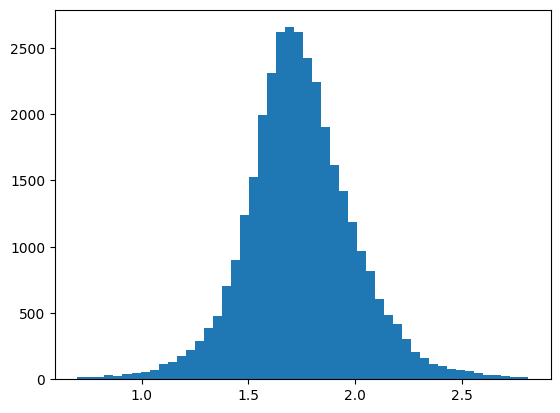

In [607]:
plt.hist(np.log10(dp_components[dp_components['N_COMP']!=1]['SIGMA'].unique()), bins=50)

plt.show()

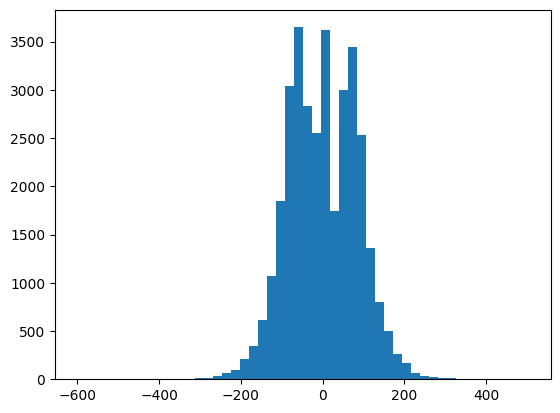

In [608]:
plt.hist((dp_components[dp_components['N_COMP']!=1]['DV'].unique()), bins=50)

plt.show()

## Eyeball a fit
Overlay data, total model, and every component for one target.

plotting TARGETID 39627758296372508  N_COMP = 4


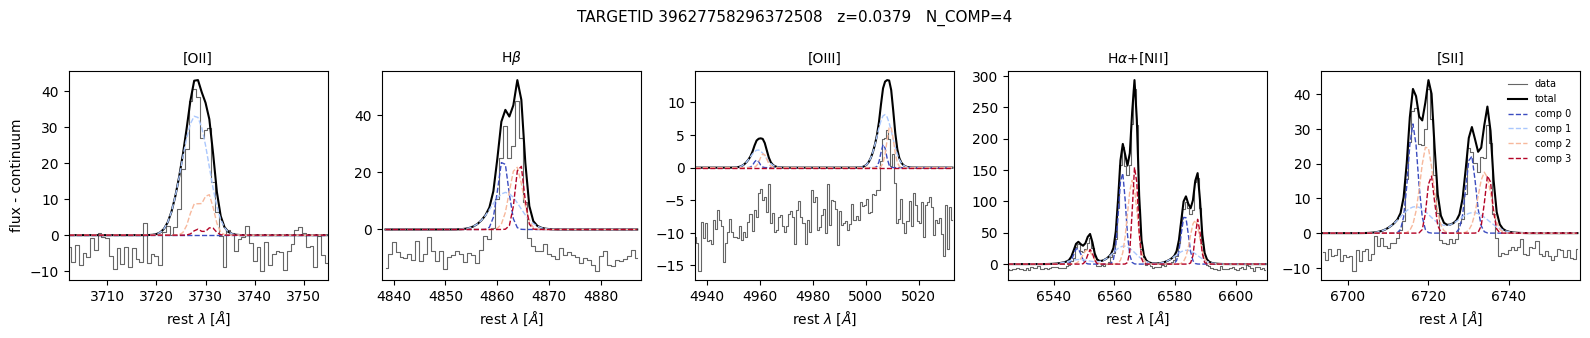

In [609]:
# prefer a multi-component target if we found one
if len(dp_sample):
    tid = int(dp_sample.sort_values('N_COMP', ascending=False)['TARGETID'].iloc[1])
else:
    tid = int(dp_parent['TARGETID'].iloc[0])
# tid = 39627793775986614
print('plotting TARGETID', tid, ' N_COMP =', int(dp_parent.loc[dp_parent['TARGETID']==tid, 'N_COMP'].iloc[0]))
fig, axes = DP.plot_fit(ALL_SPECTRA, dp_parent, dp_components, id=tid)
plt.show()

## Inspect the schema

In [610]:
print('parent columns:')
print(list(dp_parent.columns))
print()
print('component columns:')
print(list(dp_components.columns))

parent columns:
['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'N_COMP', 'N_COMP_FIT', 'BIC_1', 'CHISQ_1', 'BIC_2', 'CHISQ_2', 'BIC_3', 'CHISQ_3', 'BIC_4', 'CHISQ_4', 'OII3726_FLUX_TOT', 'OII3729_FLUX_TOT', 'Hbeta_FLUX_TOT', 'OIII4959_FLUX_TOT', 'OIII5007_FLUX_TOT', 'NII6548_FLUX_TOT', 'NII6583_FLUX_TOT', 'Halpha_FLUX_TOT', 'SII6716_FLUX_TOT', 'SII6731_FLUX_TOT', 'LOGSFR_FIT']

component columns:
['TARGETID', 'N_COMP', 'COMP_IDX', 'LINE', 'LAM0', 'DV', 'SIGMA', 'AMP', 'FLUX', 'FLUX_ERR', 'SNR', 'SIG', 'NOISE3', 'COMP_INSIG', 'BPT', 'OIII_HB_BOUND', 'NII_HA_BOUND']
